Simple Stage 1 - Attrition Rate by OverTime:
Attrition        No       Yes
OverTime                     
No         0.896422  0.103578
Yes        0.693780  0.306220


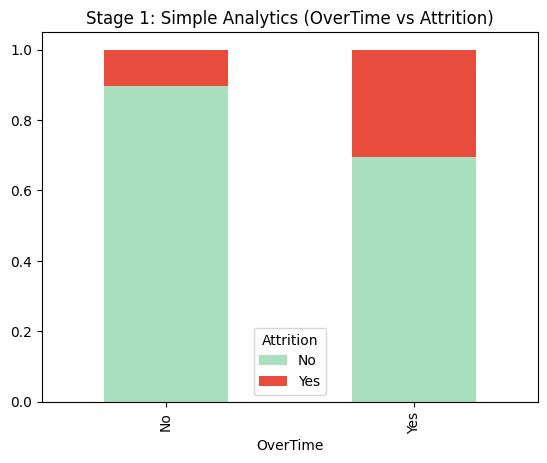

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Kaggle HR_Analytics.csv
df = pd.read_csv('HR_Analytics.csv')

# Note: Ensure Attrition is converted to 1/0 or handled as categorical
ot_impact = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index')
print("Simple Stage 1 - Attrition Rate by OverTime:")
print(ot_impact)

ot_impact.plot(kind='bar', stacked=True, color=['#A9DFBF', '#E74C3C'])
plt.title('Stage 1: Simple Analytics (OverTime vs Attrition)')
plt.show()

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Preprocessing for the Anshika2301 dataset
df_ml = df.drop(columns=['EmpID', 'EmployeeCount', 'Over18', 'StandardHours'])
le = LabelEncoder()

# Encode categorical columns
cat_cols = df_ml.select_dtypes(include=['object']).columns
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

X = df_ml.drop('Attrition', axis=1)
y = df_ml['Attrition']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Feature Importance Ranking
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Stage 2 - Improved Analytics (Top 5 Drivers):")
print(importances.head(5))

Stage 2 - Improved Analytics (Top 5 Drivers):
MonthlyIncome     0.072159
Age               0.056906
OverTime          0.053796
DailyRate         0.048248
EmployeeNumber    0.047339
dtype: float64
